### Import des librairies

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

### Chargement des données 

In [12]:
path = r"C:\Users\ajyes\OneDrive\Bureau\IBM\POST-LINKEDIN\1-variable-en-kilomètres-1-autre-en-millimètres\data\synthetic_credit_data.csv"

df = pd.read_csv(path)
df.sample(10)

,revenu_fcfa,credit_fcfa,age,score,default
115,4.452321e+06,9.505310e+05,27,4,1
547,3.695432e+06,2.400875e+06,29,2,0
863,6.693817e+06,1.917423e+06,18,5,1
483,4.305195e+06,2.259487e+06,19,5,1
32,3.979754e+06,1.929374e+06,21,1,0
39,4.295292e+06,3.302717e+06,39,5,1
1165,7.659629e+06,3.226982e+06,32,5,1
895,4.973065e+06,1.939389e+06,40,4,1
1129,4.493144e+06,2.679282e+06,37,4,1
676,2.334136e+06,1.550266e+06,25,4,1


### Visualisation sans scaling

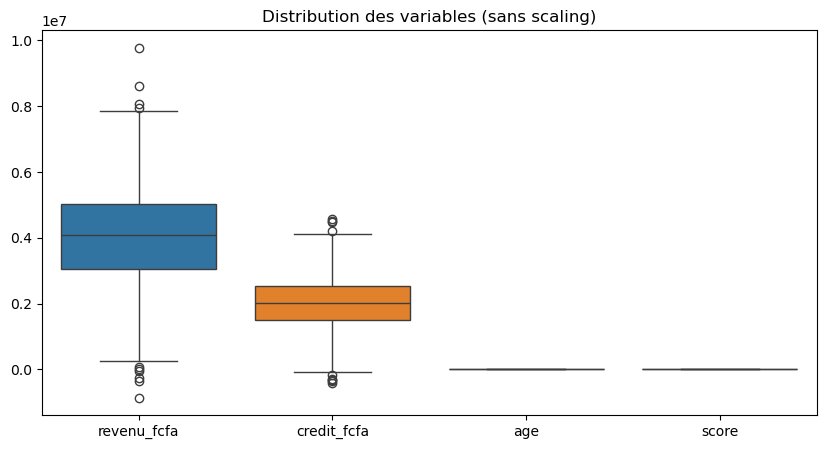

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.drop("default", axis=1))
plt.title("Distribution des variables (sans scaling)")
plt.show()

### Split

In [14]:
X = df.drop("default", axis=1)
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

### Liste des modèles

In [15]:
models = {
"KNN": KNeighborsClassifier(),
"Logistic Regression": LogisticRegression(),
"SVM": SVC(),
"Decision Tree": DecisionTreeClassifier()
} 

### Expérience SANS scaling

In [16]:
results_no_scaling = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    results_no_scaling[name] = acc

results_no_scaling 

{'KNN': 0.5833333333333334,
 'Logistic Regression': 0.9125,
 'SVM': 0.6,
 'Decision Tree': 1.0}

### Expérience AVEC scaling

In [17]:
results_scaling = {}

for name, model in models.items():
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    results_scaling[name] = acc

results_scaling

{'KNN': 0.9958333333333333,
 'Logistic Regression': 1.0,
 'SVM': 1.0,
 'Decision Tree': 1.0}

### Comparaison visuelle

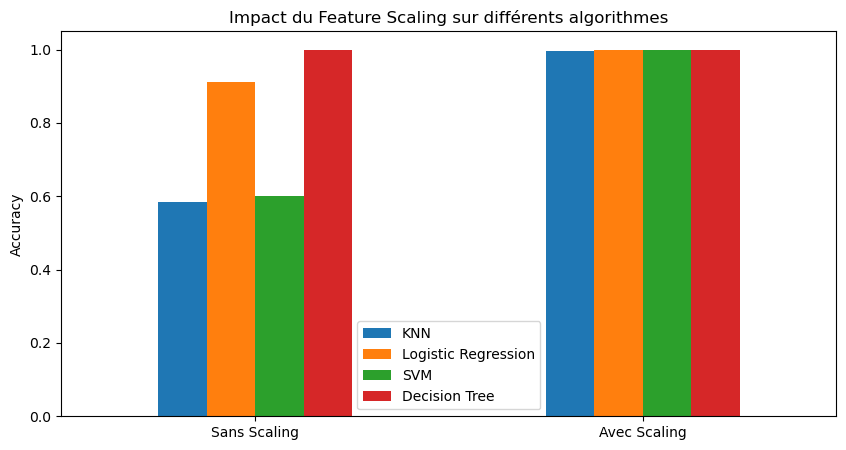

In [18]:
results_df = pd.DataFrame({
"Sans Scaling": results_no_scaling,
"Avec Scaling": results_scaling
})

results_df.T.plot(kind="bar", figsize=(10,5))

plt.title("Impact du Feature Scaling sur différents algorithmes")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()  

### Visualisation des données après scaling

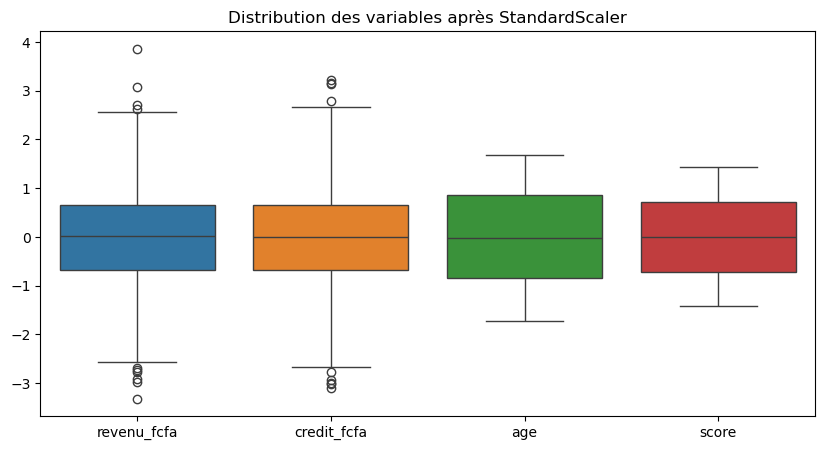

In [19]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

plt.figure(figsize=(10,5))
sns.boxplot(data=scaled_df)
plt.title("Distribution des variables après StandardScaler")
plt.show()

#### Conclusion

Les algorithmes basés sur la distance (KNN, SVM, Logistic Regression)
sont fortement affectés par l'échelle des variables.

Les modèles basés sur des arbres (Decision Trees) sont beaucoup
moins sensibles car ils utilisent des seuils de split.

Le feature scaling est donc une étape critique dans le
préprocessing des modèles de Machine Learning.